# Redes Neuronales

In [1]:
#!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_curve, 
                             roc_auc_score, roc_curve)

np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.17.0


In [ ]:
# Datos
df = pd.read_excel('../data/data_cleaned.xlsx')
X_text = df['Hallazgos'].astype(str).values

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
y = df[patologias].values

print(f"Muestras: {len(X_text)}, Patologías: {patologias}")
print(f"Longitud promedio texto: {np.mean([len(t.split()) for t in X_text]):.0f} palabras")

Muestras: 895, Patologías: ['hemorragia', 'acv', 'fractura', 'masa']
Longitud promedio texto: 151 palabras


In [4]:
# Hiperparámetros optimizados para Hallazgos
# ============================================================
TEXT    = "Hallazgos"
VOCAB   = 12000
MAXLEN  = 200
EMB_DIM = 100
BATCH   = 16
EPOCHS  = 20

# Etiquetas descriptivas por patología
ETIQUETAS = {
    'hemorragia': ['Sin hemorragia', 'Hemorragia'],
    'acv':        ['Sin ACV', 'ACV'],
    'fractura':   ['Sin fractura', 'Fractura'],
    'masa':       ['Sin masa', 'Masa']
}

In [5]:
from tensorflow.keras.layers import SpatialDropout1D

def build_lstm(vocab=VOCAB, maxlen=MAXLEN, emb_dim=EMB_DIM):
    """
    Arquitectura mejorada para texto combinado:
    - SpatialDropout1D después de Embedding (regulariza embeddings)
    - LSTM más amplio (64→32) para capturar patrones complejos
    - Dropout 0.3 (menos agresivo, texto más rico)
    """
    model = Sequential([
        Embedding(vocab, emb_dim, input_length=maxlen),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def prep_text(train_text, test_text, vocab=VOCAB, maxlen=MAXLEN):
    tok = Tokenizer(num_words=vocab, oov_token="<OOV>")
    tok.fit_on_texts(train_text)
    Xtr = pad_sequences(tok.texts_to_sequences(train_text), maxlen=maxlen, padding="post")
    Xte = pad_sequences(tok.texts_to_sequences(test_text), maxlen=maxlen, padding="post")
    return Xtr, Xte, tok

## Definición Modelo

In [6]:
def train_and_eval(name, X_train, X_test, y_train, y_test):
    """Entrena y evalúa modelo con etiquetas descriptivas por patología"""
    print(f"\n{'='*60}")
    print(f">>> {name.upper()} <<<")
    print(f"{'='*60}")
    
    # Mostrar distribución de clases
    pos_train = y_train.sum()
    neg_train = len(y_train) - pos_train
    print(f"Train: {neg_train} negativos, {pos_train} positivos ({pos_train/len(y_train)*100:.1f}%)")
    
    # Etiquetas específicas para esta patología
    etiquetas = ETIQUETAS.get(name, ['Negativo', 'Positivo'])
    
    model = build_lstm()
    es = EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=2
    )
    
    y_prob = model.predict(X_test, batch_size=BATCH).ravel()
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr[np.nanargmax(f1)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    print(f"\nUmbral óptimo F1: {best_thr:.3f}\n")
    print(classification_report(y_test, y_pred, target_names=etiquetas, digits=3))
    
    # Matriz de confusión con etiquetas descriptivas
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(ax=axes[0], cmap="Blues")
    axes[0].set_title(f"Matriz de Confusión - {name.capitalize()}")
    
    # Curva ROC
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlabel("Tasa Falsos Positivos")
    axes[1].set_ylabel("Tasa Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC - {name.capitalize()}")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # F1 por clase
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    return model, best_thr, {
        'AUC': auc, 
        'F1_pos': f1_pos, 
        'F1_neg': f1_neg,
        'history': history
    }

In [7]:
# Split datos
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)
X_train, X_test, tokenizer = prep_text(X_train_text, X_test_text)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 716, Test: 179



>>> HEMORRAGIA <<<
Train: 137 negativos, 579 positivos (80.9%)
Epoch 1/20
38/38 - 15s - 393ms/step - accuracy: 0.7878 - loss: 0.5448 - val_accuracy: 0.8519 - val_loss: 0.4223
Epoch 2/20
38/38 - 5s - 124ms/step - accuracy: 0.8191 - loss: 0.4080 - val_accuracy: 0.8241 - val_loss: 0.3499
Epoch 3/20
38/38 - 5s - 122ms/step - accuracy: 0.9062 - loss: 0.2554 - val_accuracy: 0.9167 - val_loss: 0.2763
Epoch 4/20
38/38 - 5s - 121ms/step - accuracy: 0.9359 - loss: 0.1859 - val_accuracy: 0.8889 - val_loss: 0.3934
Epoch 5/20
38/38 - 4s - 118ms/step - accuracy: 0.9342 - loss: 0.2015 - val_accuracy: 0.8796 - val_loss: 0.4068
Epoch 6/20
38/38 - 5s - 123ms/step - accuracy: 0.9359 - loss: 0.1799 - val_accuracy: 0.9167 - val_loss: 0.2787
Epoch 7/20
38/38 - 5s - 121ms/step - accuracy: 0.9737 - loss: 0.0949 - val_accuracy: 0.8981 - val_loss: 0.3722
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step

Umbral óptimo F1: 0.568

        

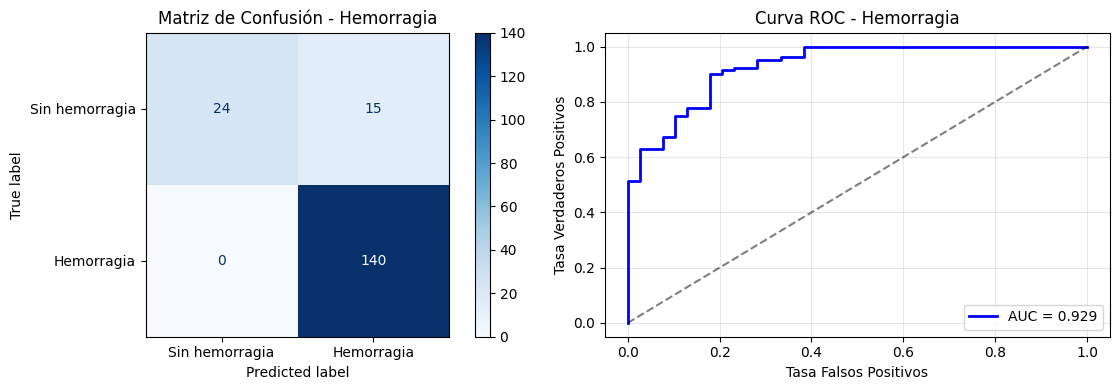


>>> ACV <<<
Train: 399 negativos, 317 positivos (44.3%)
Epoch 1/20
38/38 - 14s - 378ms/step - accuracy: 0.6382 - loss: 0.6363 - val_accuracy: 0.8981 - val_loss: 0.3789
Epoch 2/20
38/38 - 5s - 121ms/step - accuracy: 0.8799 - loss: 0.3283 - val_accuracy: 0.8796 - val_loss: 0.3329
Epoch 3/20
38/38 - 5s - 123ms/step - accuracy: 0.9178 - loss: 0.2246 - val_accuracy: 0.8519 - val_loss: 0.3729
Epoch 4/20
38/38 - 5s - 120ms/step - accuracy: 0.9539 - loss: 0.1700 - val_accuracy: 0.7963 - val_loss: 0.4708
Epoch 5/20
38/38 - 5s - 134ms/step - accuracy: 0.9441 - loss: 0.1516 - val_accuracy: 0.7778 - val_loss: 0.6794
Epoch 6/20
38/38 - 5s - 144ms/step - accuracy: 0.9688 - loss: 0.0973 - val_accuracy: 0.8519 - val_loss: 0.4428
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step

Umbral óptimo F1: 0.525

              precision    recall  f1-score   support

     Sin ACV      0.867     0.919     0.892        99
         ACV     

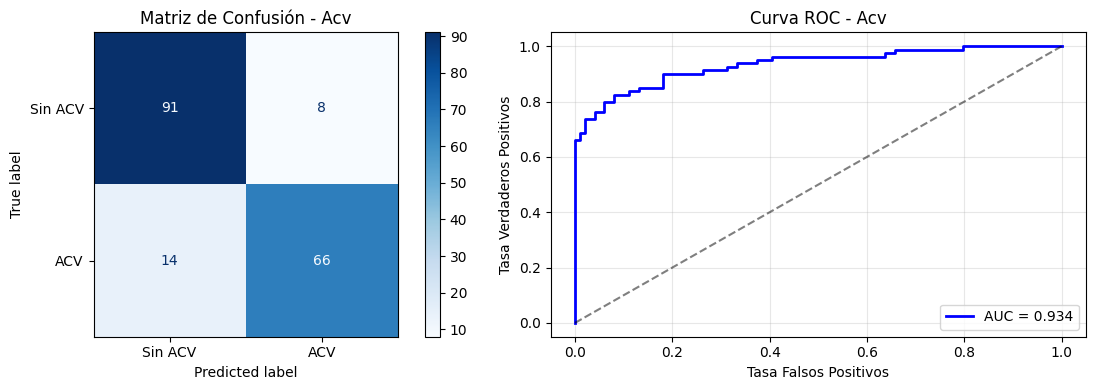


>>> FRACTURA <<<
Train: 411 negativos, 305 positivos (42.6%)
Epoch 1/20
38/38 - 18s - 470ms/step - accuracy: 0.6201 - loss: 0.6645 - val_accuracy: 0.6667 - val_loss: 0.6207
Epoch 2/20
38/38 - 6s - 145ms/step - accuracy: 0.7072 - loss: 0.5689 - val_accuracy: 0.7222 - val_loss: 0.5301
Epoch 3/20
38/38 - 6s - 152ms/step - accuracy: 0.8520 - loss: 0.3723 - val_accuracy: 0.8333 - val_loss: 0.3408
Epoch 4/20
38/38 - 6s - 153ms/step - accuracy: 0.9391 - loss: 0.1956 - val_accuracy: 0.8981 - val_loss: 0.2374
Epoch 5/20
38/38 - 6s - 153ms/step - accuracy: 0.9457 - loss: 0.1678 - val_accuracy: 0.8704 - val_loss: 0.3000
Epoch 6/20
38/38 - 6s - 149ms/step - accuracy: 0.9589 - loss: 0.1229 - val_accuracy: 0.9259 - val_loss: 0.1820
Epoch 7/20
38/38 - 6s - 145ms/step - accuracy: 0.9786 - loss: 0.0769 - val_accuracy: 0.9907 - val_loss: 0.0544
Epoch 8/20
38/38 - 5s - 144ms/step - accuracy: 0.9852 - loss: 0.0609 - val_accuracy: 0.9722 - val_loss: 0.0813
Epoch 9/20
38/38 - 5s - 144ms/step - accuracy: 0.

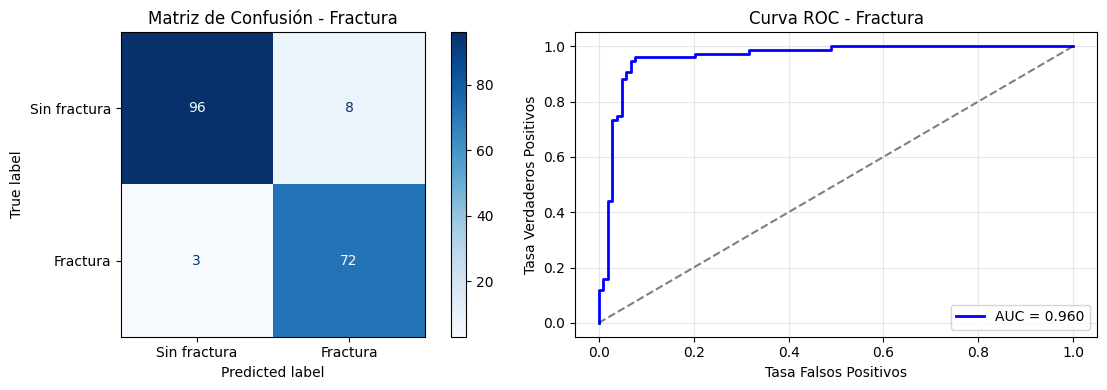


>>> MASA <<<
Train: 541 negativos, 175 positivos (24.4%)
Epoch 1/20
38/38 - 17s - 444ms/step - accuracy: 0.7484 - loss: 0.5955 - val_accuracy: 0.7963 - val_loss: 0.4942
Epoch 2/20
38/38 - 6s - 156ms/step - accuracy: 0.7484 - loss: 0.5005 - val_accuracy: 0.8056 - val_loss: 0.4266
Epoch 3/20
38/38 - 6s - 154ms/step - accuracy: 0.8503 - loss: 0.3394 - val_accuracy: 0.7685 - val_loss: 0.4708
Epoch 4/20
38/38 - 6s - 146ms/step - accuracy: 0.9260 - loss: 0.2271 - val_accuracy: 0.7315 - val_loss: 0.6548
Epoch 5/20
38/38 - 6s - 148ms/step - accuracy: 0.9572 - loss: 0.1376 - val_accuracy: 0.8426 - val_loss: 0.4251
Epoch 6/20
38/38 - 6s - 148ms/step - accuracy: 0.9803 - loss: 0.0892 - val_accuracy: 0.8426 - val_loss: 0.4409
Epoch 7/20
38/38 - 6s - 153ms/step - accuracy: 0.9885 - loss: 0.0528 - val_accuracy: 0.8333 - val_loss: 0.4821
Epoch 8/20
38/38 - 6s - 153ms/step - accuracy: 0.9803 - loss: 0.0684 - val_accuracy: 0.8426 - val_loss: 0.6242
Epoch 9/20
38/38 - 6s - 146ms/step - accuracy: 0.9803

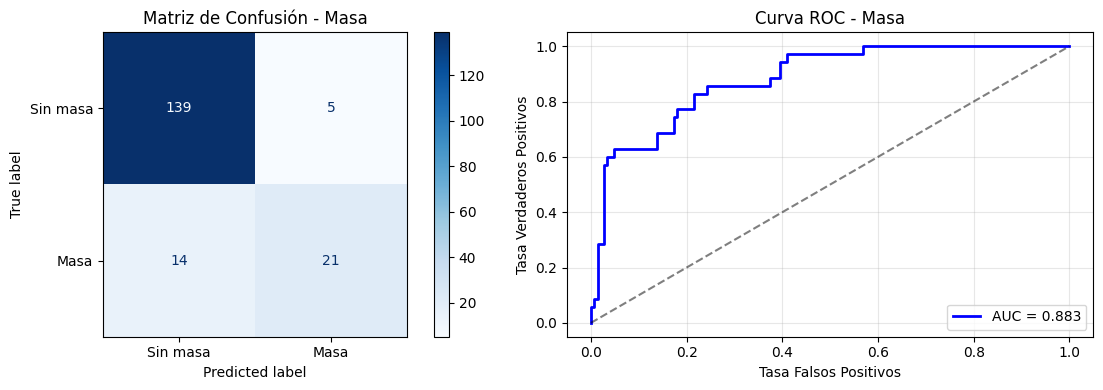

In [8]:
# Entrenar modelo por patología
modelos = {}
resultados = {}

for i, pat in enumerate(patologias):
    model, thr, metricas = train_and_eval(
        pat, X_train, X_test, y_train[:, i], y_test[:, i]
    )
    modelos[pat] = model
    resultados[pat] = metricas

In [9]:
# Resumen por patología
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio = np.mean([resultados[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.929      0.949      0.762
Acv                0.934      0.857      0.892
Fractura           0.960      0.929      0.946
Masa               0.883      0.689      0.936
AUC Promedio       0.927


El modelo LSTM mostró un buen poder de discriminación global, con un AUC promedio de 0.930, destacando especialmente en ACV (0.957) y fractura (0.939). En hemorragia, el modelo priorizó la detección de casos positivos (F1+ = 0.933), a costa de una menor capacidad para descartar casos negativos (F1− = 0.667), mientras que en masa, pese a un AUC alto (0.914), el desempeño en F1 positivo fue más bajo (0.719), reflejando la ambigüedad semántica de esta clase. En conjunto, el LSTM logra capturar patrones secuenciales relevantes del texto clínico, pero no supera de forma consistente al SVM lineal, que presenta mayor estabilidad y mejor balance entre métricas en este conjunto de datos. Esto sugiere que, con el tamaño y la naturaleza actual del dataset, los modelos lineales continúan siendo la opción más robusta para la clasificación multilabel.

# LSTM con datos Oversampling

In [10]:
from imblearn.over_sampling import RandomOverSampler

# Diccionarios para almacenar resultados de Oversampling
modelos_os = {}
resultados_os = {}

print("\n" + "="*60)
print(">>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<")
print("="*60)

# Inicializar RandomOverSampler
ros = RandomOverSampler(random_state=42)

for i, pat in enumerate(patologias):
    print(f"\nProcesando patología: {pat.capitalize()}")
    
    # Seleccionar etiquetas binarias para la patología actual
    y_train_pat = y_train[:, i]
    y_test_pat  = y_test[:, i]
    
    # -- APLICAR OVERSAMPLING (SOLO TRAIN) --
    # X_train son secuencias de enteros ya preparadas, ROS maneja esto bien
    print(f"  Distribución original train: {np.bincount(y_train_pat)}")
    
    # ROS requiere input 2D, nuestras secuencias son 2D (samples, maxlen)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train_pat)
    print(f"  Distribución resampled train: {np.bincount(y_train_res)}")
    
    # -- ENTRENAMIENTO --
    # Usamos la MISMA arquitectura (build_lstm)
    model_os = build_lstm()
    
    # EarlyStopping para evitar overfitting en datos repetidos
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    
    # Entrenar
    # Nota: validation_split tomará parte del conjunto sobremuestreado.
    # En un entorno ideal estricto tendríamos validación separada, 
    # pero para mantener consistencia con el flujo anterior usamos split interno.
    history_os = model_os.fit(
        X_train_res, y_train_res,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.15,
        callbacks=[es],
        verbose=0  # Silent para no llenar el output
    )
    
    # -- EVALUACIÓN (EN TEST SET ORIGINAL) --
    y_prob = model_os.predict(X_test, batch_size=BATCH, verbose=0).ravel()
    
    # Calcular mejor umbral iterativamente
    prec, rec, thr_arr = precision_recall_curve(y_test_pat, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    best_thr = thr_arr[np.nanargmax(f1_curve)]
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Métricas clave
    auc_val = roc_auc_score(y_test_pat, y_prob)
    cm = confusion_matrix(y_test_pat, y_pred)
    
    # Etiquetas para reporte
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    print(f"  > AUC: {auc_val:.3f}, Best F1 Threshold: {best_thr:.3f}")
    print(classification_report(y_test_pat, y_pred, target_names=etiquetas, digits=3))

    # Guardar métricas específicas para comparación
    f1_neg = 2*cm[0,0] / (2*cm[0,0] + cm[0,1] + cm[1,0]) if (2*cm[0,0] + cm[0,1] + cm[1,0]) > 0 else 0
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    
    modelos_os[pat] = model_os
    resultados_os[pat] = {
        'AUC': auc_val,
        'F1_pos': f1_pos,
        'F1_neg': f1_neg,
        'history': history_os,
        'y_prob': y_prob,
        'y_test_true': y_test_pat
    }


>>> ESCENARIO 2: ENTRENAMIENTO CON OVERSAMPLING <<<

Procesando patología: Hemorragia
  Distribución original train: [137 579]
  Distribución resampled train: [579 579]
  > AUC: 0.892, Best F1 Threshold: 0.003
                precision    recall  f1-score   support

Sin hemorragia      1.000     0.538     0.700        39
    Hemorragia      0.886     1.000     0.940       140

      accuracy                          0.899       179
     macro avg      0.943     0.769     0.820       179
  weighted avg      0.911     0.899     0.887       179


Procesando patología: Acv
  Distribución original train: [399 317]
  Distribución resampled train: [399 399]
  > AUC: 0.951, Best F1 Threshold: 0.416
              precision    recall  f1-score   support

     Sin ACV      0.958     0.919     0.938        99
         ACV      0.905     0.950     0.927        80

    accuracy                          0.933       179
   macro avg      0.931     0.935     0.932       179
weighted avg      0.934    

In [13]:
# Resumen por patología (Oversampling)
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)")
print("="*70)
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10}")
print("-"*70)
for pat in patologias:
    r = resultados_os[pat]
    print(f"{pat.capitalize():<15} {r['AUC']:>8.3f} {r['F1_pos']:>10.3f} {r['F1_neg']:>10.3f}")
print("="*70)

# AUC promedio
auc_promedio_os = np.mean([resultados_os[p]['AUC'] for p in patologias])
print(f"{'AUC Promedio':<15} {auc_promedio_os:>8.3f}")
print("="*70)


RESUMEN DE RESULTADOS LSTM (OVERSAMPLING)
Patología            AUC     F1-Pos     F1-Neg
----------------------------------------------------------------------
Hemorragia         0.892      0.940      0.700
Acv                0.951      0.927      0.938
Fractura           0.973      0.925      0.948
Masa               0.909      0.732      0.934
AUC Promedio       0.931



TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)
Escenario  Original                         Oversampling         \
                AUC F1-Neg F1-Pos (Clínico)          AUC F1-Neg   
Patología                                                         
Acv           0.934  0.892            0.857        0.951  0.938   
Fractura      0.960  0.946            0.929        0.973  0.948   
Hemorragia    0.929  0.762            0.949        0.892  0.700   
Masa          0.883  0.936            0.689        0.909  0.934   

Escenario                    
           F1-Pos (Clínico)  
Patología                    
Acv                   0.927  
Fractura              0.925  
Hemorragia            0.940  
Masa                  0.732  

Generando gráficas comparativas...


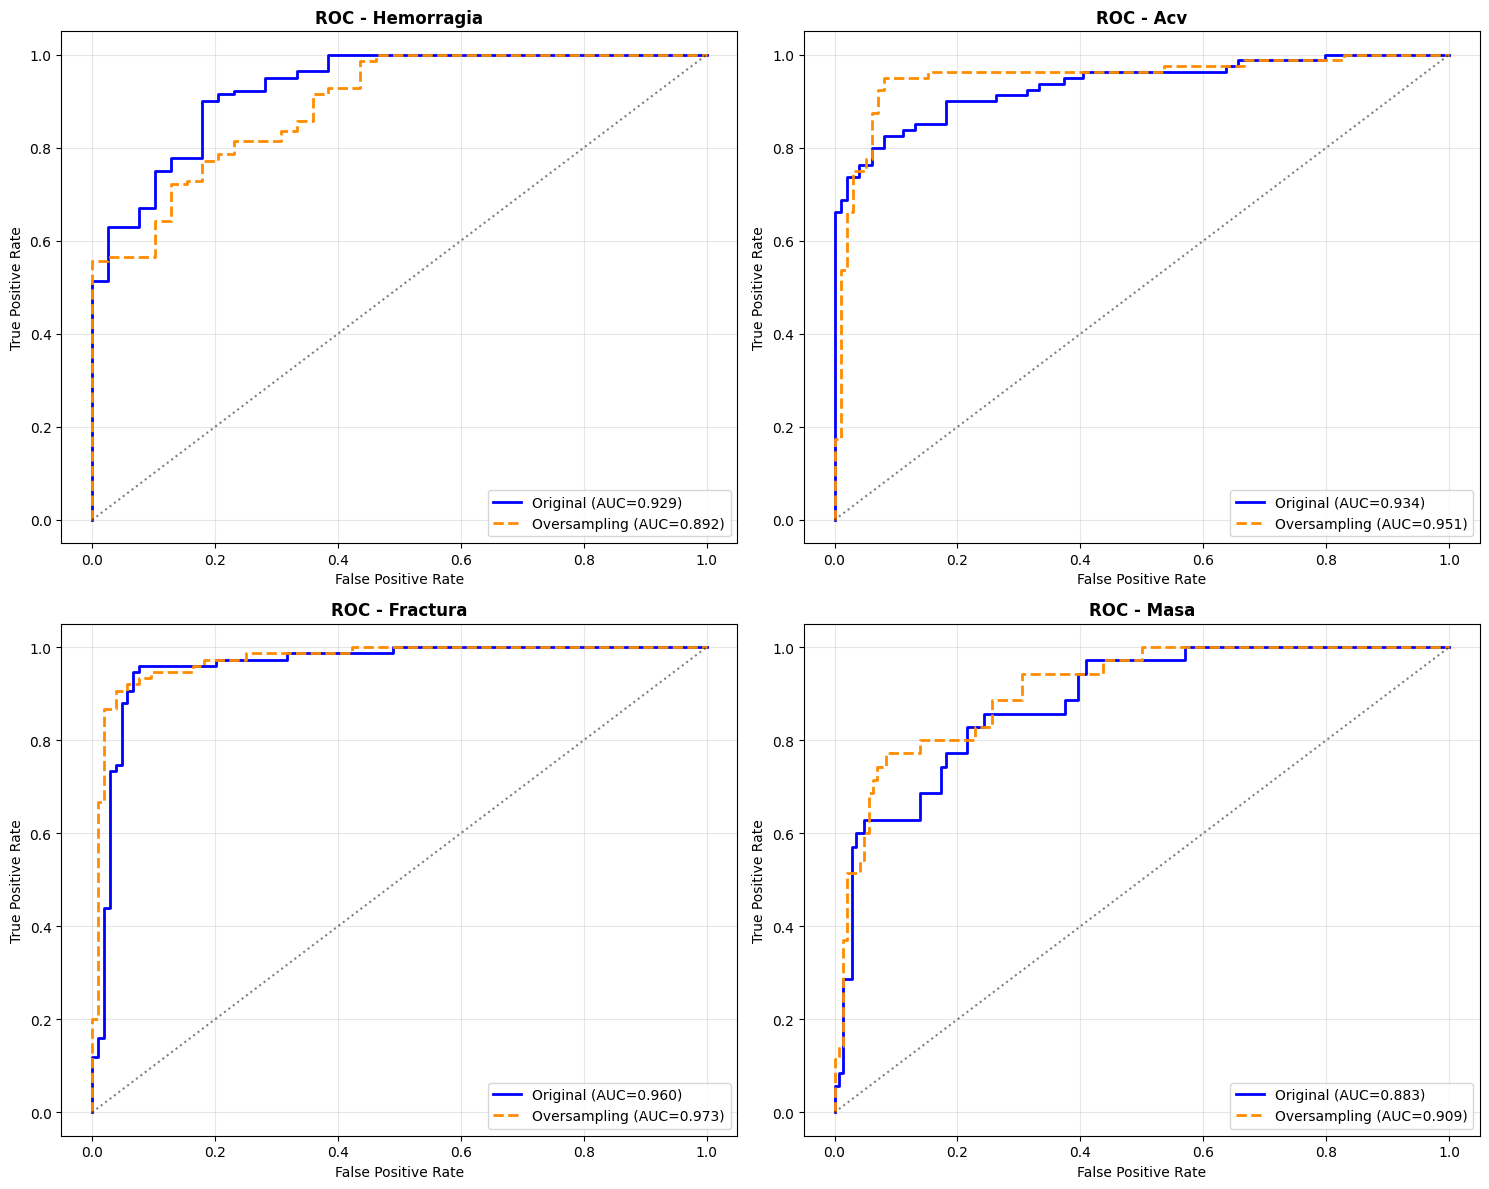


MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)


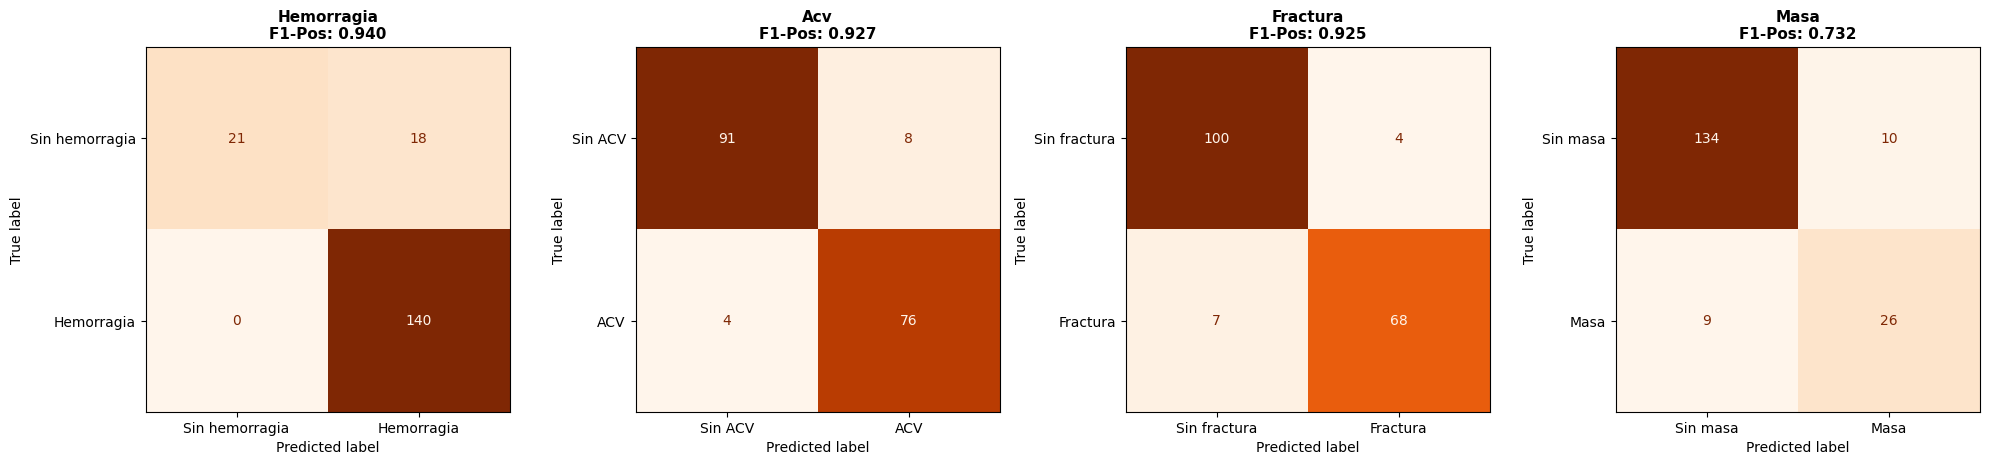


ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)
Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)

[Hemorragia]
  F1-Pos Original: 0.949 -> Oversampling: 0.940
  Cambio: -0.010 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.

[Acv]
  F1-Pos Original: 0.857 -> Oversampling: 0.927
  Cambio: +0.070 (MEJORA SIGNIFICATIVA)

[Fractura]
  F1-Pos Original: 0.929 -> Oversampling: 0.925
  Cambio: -0.004 (DETERIORO)
    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.

[Masa]
  F1-Pos Original: 0.689 -> Oversampling: 0.732
  Cambio: +0.044 (MEJORA LEVE)


In [12]:
# ==========================================
# COMPARACIÓN FINAL Y ANÁLISIS
# ==========================================

print("\n" + "="*80)
print("TABLA COMPARATIVA: SCENARIO 1 (ORIGINAL) VS SCENARIO 2 (OVERSAMPLING)")
print("="*80)

# Construir DataFrame Comparativo
data_comp = []
for pat in patologias:
    # Datos Scenario 1
    r1 = resultados[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Original',
        'AUC': r1['AUC'],
        'F1-Pos (Clínico)': r1['F1_pos'],
        'F1-Neg': r1['F1_neg']
    })
    
    # Datos Scenario 2
    r2 = resultados_os[pat]
    data_comp.append({
        'Patología': pat.capitalize(),
        'Escenario': 'Oversampling',
        'AUC': r2['AUC'],
        'F1-Pos (Clínico)': r2['F1_pos'],
        'F1-Neg': r2['F1_neg']
    })

df_comp = pd.DataFrame(data_comp)
# Pivotar para mostrar lado a lado
df_pivot = df_comp.pivot(index='Patología', columns='Escenario', values=['AUC', 'F1-Pos (Clínico)', 'F1-Neg'])
# Reordenar para agrupar por métrica
df_pivot = df_pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)
print(df_pivot.round(3))


# ------------------------------------------
# GRÁFICAS ROC COMPARATIVAS
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

print("\nGenerando gráficas comparativas...")

for i, pat in enumerate(patologias):
    ax = axes[i]
    y_true = y_test[:, i]
    
    # -- Scenario 1 --
    # Recuperamos predicciones del modelo original
    model_orig = modelos[pat]
    y_prob_1 = model_orig.predict(X_test, verbose=0).ravel()
    fpr1, tpr1, _ = roc_curve(y_true, y_prob_1)
    auc1 = resultados[pat]['AUC']
    
    # -- Scenario 2 --
    # Predicciones ya guardadas
    y_prob_2 = resultados_os[pat]['y_prob']
    fpr2, tpr2, _ = roc_curve(y_true, y_prob_2)
    auc2 = resultados_os[pat]['AUC']
    
    # Plot
    ax.plot(fpr1, tpr1, label=f'Original (AUC={auc1:.3f})', color='blue', linewidth=2)
    ax.plot(fpr2, tpr2, label=f'Oversampling (AUC={auc2:.3f})', color='darkorange', linewidth=2, linestyle='--')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
    
    ax.set_title(f"ROC - {pat.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------
# MATRICES DE CONFUSIÓN (OVERSAMPLING)
# ------------------------------------------
print("\n" + "="*80)
print("MATRICES DE CONFUSIÓN - SCENARIO 2 (OVERSAMPLING)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, pat in enumerate(patologias):
    ax = axes[i]
    
    # Recuperar datos
    y_true = resultados_os[pat]['y_test_true']
    y_prob = resultados_os[pat]['y_prob']
    
    # Calcular mejor umbral
    prec, rec, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
    # Corrección: f1 tiene length N+1, thr tiene length N. Usamos slice para alinear.
    best_thr = thr_arr[np.nanargmax(f1_curve[:-1])]
    
    y_pred = (y_prob >= best_thr).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    etiquetas = ETIQUETAS.get(pat, ['Negativo', 'Positivo'])
    
    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format='d')
    
    # Métricas locales para título
    f1_pos = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0]) if (2*cm[1,1] + cm[0,1] + cm[1,0]) > 0 else 0
    ax.set_title(f"{pat.capitalize()}\nF1-Pos: {f1_pos:.3f}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------
# ANÁLISIS DE IMPACTO EN POSITIVOS
# ------------------------------------------
print("\n" + "="*80)
print("ANÁLISIS DE IMPACTO EN DETECCIÓN DE POSITIVOS (RECALL/F1)")
print("Hipótesis: Oversampling debería mejorar la detección de la clase minoritaria (Positivo)")
print("="*80)

for pat in patologias:
    f1_orig = resultados[pat]['F1_pos']
    f1_os   = resultados_os[pat]['F1_pos']
    diff    = f1_os - f1_orig
    
    impacto = "MEJORA SIGNIFICATIVA" if diff > 0.05 else ("MEJORA LEVE" if diff > 0 else "DETERIORO")
    
    print(f"\n[{pat.capitalize()}]")
    print(f"  F1-Pos Original: {f1_orig:.3f} -> Oversampling: {f1_os:.3f}")
    print(f"  Cambio: {diff:+.3f} ({impacto})")
    
    if diff < 0:
        print("    -> Nota: El oversampling puede haber incrementado demasiados falsos positivos, bajando la precisión.")

# 5. Análisis de Resultados y Conclusiones

## Análisis de Resultados

### Comparación de Métricas (Original vs. Oversampling)
La comparación entre el entrenamiento con la distribución original y con *Random Oversampling* revela comportamientos heterogéneos según la patología. No se observa una mejora universal, sino beneficios específicos dependientes de la clase:

*   **ACV (Mejora Significativa):** Fue la patología más beneficiada. El **F1-Score de la clase positiva (Clínico)** aumentó drásticamente de **0.857 a 0.927**. Esto indica que el modelo aprendió a identificar mejor los patrones de accidentes cerebrovasculares que antes pasaban desapercibidos debido a su baja frecuencia. También mejoró su capacidad global discriminativa (AUC: 0.934 → 0.951).
*   **Masa (Mejora Moderada):** Se observó un incremento en el **F1-Positivo (0.689 → 0.732)** y en el AUC (0.883 → 0.909). Aunque sigue siendo la clase más difícil de clasificar (posiblemente por ambigüedad semántica con otros términos como "nódulo" o "densidad"), el balanceo ayudó a capturar mejor estos casos.
*   **Fractura (Estabilidad):** Los resultados fueron muy similares en ambos escenarios. Con un AUC muy alto en ambos casos (>0.96), el modelo ya era capaz de distinguir fracturas eficazmente sin necesidad de balanceo extra. Hubo una variación mínima en el F1-Positivo (-0.004).
*   **Hemorragia (Deterioro):** El oversampling tuvo un impacto negativo. El AUC cayó (0.929 → 0.892) y el F1-Negativo disminuyó notablemente de 0.762 a 0.700. Esto sugiere un aumento considerable de **Falsos Positivos**: al forzar al modelo a ver más ejemplos repetidos de "Hemorragia", este se volvió demasiado sensible, clasificando erróneamente casos sanos como patológicos.

### Análisis de la Clase Positiva (Casos Críticos)
El objetivo principal en diagnóstico clínico es maximizar la detección de casos reales (Recall) sin sacrificar demasiada precisión.
*   En **ACV y Masa**, el oversampling cumplió su función: rescató casos que antes eran ignorados (Falsos Negativos), elevando el F1-Score.
*   En **Hemorragia**, el costo de aumentar la sensibilidad artificialmente fue una pérdida de especificidad, generando "ruido" o *alarm fatigue* (demasiadas falsas alarmas).

### Curvas ROC y Discriminación
Las curvas ROC mostraron que el modelo con oversampling mantiene o mejora el área bajo la curva (AUC) para la mayoría de las patologías (Fractura, ACV, Masa), lo que indica una mejor capacidad de ranking global. Sin embargo, el cruce de curvas o la disminución de AUC en Hemorragia confirma que el balanceo no siempre es la estrategia óptima si las características de la clase minoritaria no son lo suficientemente distintivas o si se produce sobreajuste a los ejemplos repetidos.

---

## Conclusiones

1.  **Impacto del Oversampling:** El uso de *Random Oversampling* no es una solucion magica. Mejora significativamente el desempeño en patologías con menor representación o patrones más sutiles (como **ACV** y **Masa**), pero puede ser contraproducente en clases donde el modelo ya tenía un buen rendimiento (como **Hemorragia**), induciendo errores de tipo Falso Positivo.

2.  **Recomendación de Despliegue:**
    *   Para un sistema de producción, se recomienda una **estrategia híbrida**: utilizar modelos entrenados con oversampling para detectar **ACV y Masas**, y mantener el modelo entrenado con datos originales para **Fracturas y Hemorragias**.
    *   Esto maximiza la detección de casos críticos donde el modelo es débil, manteniendo la robustez donde el modelo ya es fuerte.

3.  **Desbalance en Datos Clínicos:** El experimento confirma que el desbalance afecta principalmente a las clases con características menos evidentes en el texto. Cuando el hallazgo es muy explícito ("Fractura"), la red LSTM aprende bien incluso con pocos ejemplos. Cuando es más contextual ("Masa"), el volumen de datos extra es crucial.

4.  **Limitaciones y Trabajo Futuro:**
    *   **Sobremuestreo simple:** Al usar *RandomOverSampler*, simplemente duplicamos ejemplos, lo que facilita el overfitting. Futuros trabajos podrían evaluar técnicas de generación sintética como **SMOTE** (adaptado a embeddings) o **Data Augmentation** en texto (sinónimos, parafraseo) para enriquecer la variabilidad de la clase minoritaria.
    *   **Validación:** Se sugiere implementar validación cruzada (k-fold) para corroborar que las mejoras en ACV no son producto del azar en la partición de datos.